# Master MIND - IDLE

# Entraînement en PyTorch

------------------------------------------------------------------------

**Remarque:** Si vous arrivez ici sans avoir lu les instructions
d’installation sur la page du cours, ça ne va pas marcher. Goto
<https://schwander.isir.upmc.fr/enseignement/m1mind_idle/> dans ce cas.


In [1]:
import pandas as pd
import numpy as np
from scipy.io import arff
import matplotlib.pyplot as plt

from sklearn.preprocessing import OneHotEncoder

import torch
from torch.utils.data import Dataset, DataLoader, random_split
from sklearn.datasets import fetch_openml
from torch import nn
from torch.functional import F
from torch import optim

import lightning.pytorch as pl


# Exercice 1 - *Dataset* *personnalisé*

Pour se compliquer la vie, on va faire l’apprentissage sur un dataset
qui n’est pas disponible directement dans PyTorch. Il s’agit
d’[USPS](https://www.openml.org/search?type=data&sort=runs&id=41070&status=active),
un petit dataset de chiffres manuscrits avec des images $16 \times 16$.
On a seulement 9000 images, c’est donc beaucoup plus facile à gérer que
MNIST.

## Question 1 - *Exploration* *préliminaire*

Avec le module `pandas` ou `polars`, analyser rapidement le contenu du
dataset.

In [2]:
data_raw, meta = arff.loadarff('usps.arff')
usps_df = pd.DataFrame(data_raw)

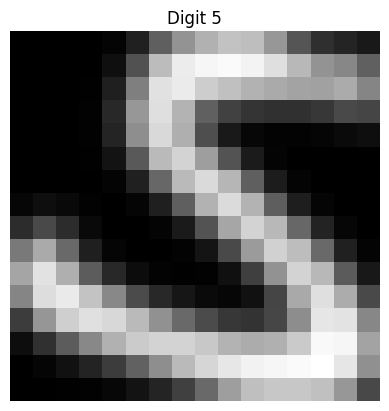

In [3]:
idx = 734
img_test, lab = usps_df.iloc[idx,1:].to_numpy().reshape(16,16), usps_df.iloc[idx,0]
plt.imshow(img_test, cmap="grey")
plt.axis("off")
plt.title(f"Digit {int(lab-1)}");

## Question 2 - `Dataset` *Pytorch*

Le chargement proprement dit s’effectuera avec la fonction
`sklearn.datasets.fetch_openml`. Il s’agit donc simplement d’écrire un
emballage autour des données brutes pour permettre l’accès facilement
par PyTorch.

**Remarque**: rien n’oblige à utiliser un `DataLoader`, mais il n’y a
pas vraiment de raison de s’en priver.

In [4]:
class USPSDataset(Dataset):
    def __init__(self, train=True, test_prop = 0.2, seed=42):
        raw_data = fetch_openml("usps")
        full_data = raw_data["data"].values

        label = raw_data["target"].astype(int)

        encoder = OneHotEncoder(
            categories=[np.sort(np.unique(label))],
            sparse_output = False
        )
        
        one_hot_label = encoder.fit_transform(
            pd.DataFrame(label)
            )

        full_label = one_hot_label.astype(float)

        generator = torch.Generator().manual_seed(seed)

        idx = torch.randperm(full_data.shape[0], generator=generator)
        test_id = int(test_prop*full_data.shape[0])

        if train:
            idx = idx[test_id:]
        else:
            idx = idx[:test_id]

        self.data = torch.tensor(full_data[idx,:], dtype=torch.float32)
        self.labels = torch.tensor(full_label[idx,:], dtype=torch.float32)

    def __len__(self):
        return self.labels.shape[0]

    def __getitem__(self, idx):
        sample = self.data[idx]
        label = self.labels[idx]
        return sample, label

dataset_train = USPSDataset(train=True)
dataset_val = USPSDataset(train=False)
batch_size = 100
loader_train = DataLoader(dataset_train, batch_size=batch_size, shuffle=True)
loader_val = DataLoader(dataset_val, batch_size=batch_size, shuffle=False)

/Users/vlad/Documents/University/Master-MIND/M1-S2-MIND/IDLE/tme/tme02/.venv/lib/python3.13/site-packages/sklearn/datasets/_openml.py:328: UserWarning: Multiple active versions of the dataset matching the name usps exist. Versions may be fundamentally different, returning version 2. Available versions:
- version 2, status: active
  url: https://www.openml.org/search?type=data&id=41082
- version 3, status: active
  url: https://www.openml.org/search?type=data&id=41964

  warn(warning_msg)
/Users/vlad/Documents/University/Master-MIND/M1-S2-MIND/IDLE/tme/tme02/.venv/lib/python3.13/site-packages/sklearn/datasets/_openml.py:328: UserWarning: Multiple active versions of the dataset matching the name usps exist. Versions may be fundamentally different, returning version 2. Available versions:
- version 2, status: active
  url: https://www.openml.org/search?type=data&id=41082
- version 3, status: active
  url: https://www.openml.org/search?type=data&id=41964

  warn(warning_msg)


## Question 3 - *Entraînement* *d’un* *modèle* *simple*

Construire un MLP avec une couche cachée.

In [5]:
class SimpleMLP(nn.Module):
    def __init__(self) -> None:
        super().__init__()
        self.fc1 = nn.Linear(256, 512)
        self.fc2 = nn.Linear(512, 10)
    
    def forward(self, x):
        x = x.view(x.size(0),-1) # TODO: why?
        x = F.relu(self.fc1(x))
        x =  self.fc2(x)
        return F.softmax(x,1)

Réaliser l’entraînement avec l’optimiser Adam. On n’oubliera pas
l’évaluation.

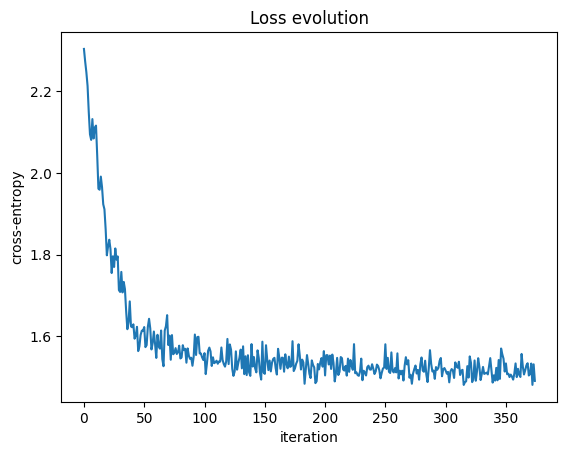

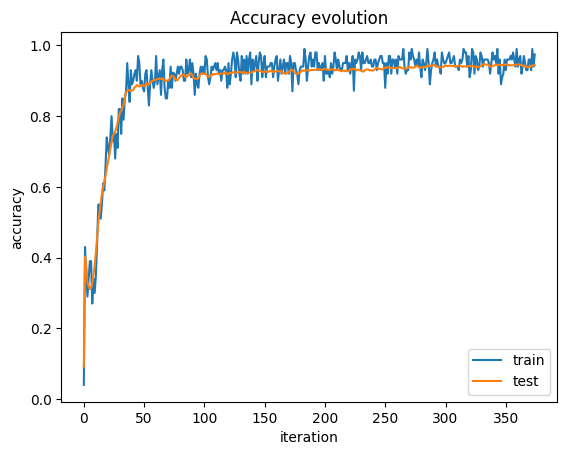

In [ ]:
model = SimpleMLP()
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)
max_iter = 5
losses = []
train_scores = []
test_scores = []
for epoch in range(max_iter):
    model.train()
    for batch_x, batch_y in loader_train:
        optimizer.zero_grad()
        outputs = model(batch_x)
        loss = criterion(outputs, batch_y)
        losses.append(loss.item())
        loss.backward()
        train_scores.append((outputs.argmax(1)==batch_y.argmax(1)).sum().item() / batch_y.size(0))

        # NOTE: for bigger datasets evaluate per epoch, not per batch
        # for loss - average it over batches
        model.eval()
        total = correct = 0
        with torch.no_grad():
            
            for batch_x, batch_y in loader_val:
                outputs = model(batch_x)
                predicted = outputs.argmax(1)
                total += batch_y.size(0)
                correct += (predicted==batch_y.argmax(1)).sum().item()
            test_scores.append(correct/total)
        optimizer.step()

plt.plot(range(len(losses)), losses)
plt.title("Loss evolution")
plt.ylabel("cross-entropy")
plt.xlabel("iteration")
plt.show()

plt.plot(range(len(train_scores)), train_scores, label="train")
plt.plot(range(len(test_scores)), test_scores, label="test")
plt.legend()
plt.title("Accuracy evolution")
plt.ylabel("accuracy")
plt.xlabel("iteration")
plt.show()

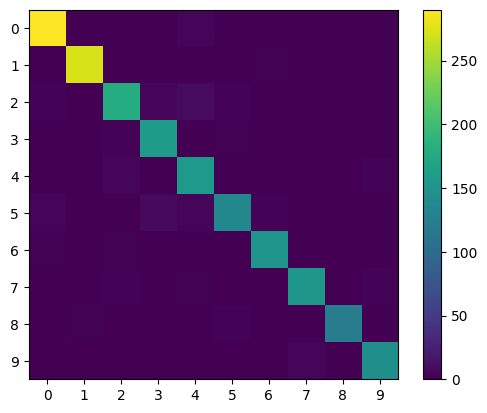

In [18]:
model.eval()
conf_maxtix = torch.zeros((10,10))
with torch.no_grad():
    for batch_x, batch_y in loader_val:
        outputs = model(batch_x)
        for t, p in zip(batch_y.argmax(1), outputs.argmax(1)):
            conf_maxtix[t,p] += 1
plt.imshow(conf_maxtix)
plt.xticks(range(10))
plt.yticks(range(10))
plt.colorbar()

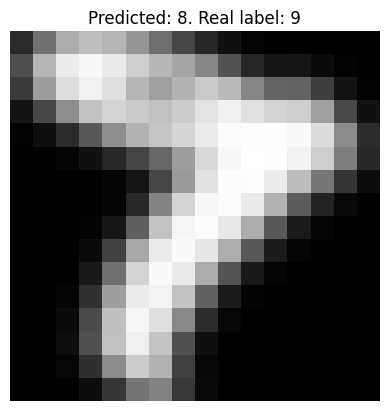

In [27]:
i = torch.where(outputs.argmax(1)!=batch_y.argmax(1))[0][0]
plt.imshow(batch_x[i].numpy().reshape(16,16), cmap="grey")
plt.title(f"Predicted: {outputs[i].argmax().item()}. Real label: {batch_y[i].argmax()}")
plt.axis("off")
plt.show()

Adapter la boucle d’entraînement pour conserver les valeurs des loss et
des accuracys au cours des epochs.

Tracer et analyser les courbes associées, en train et en val. Imaginer
les courbes correspondants au cas suivants:

-   optimisation qui ne fonctionne pas du tout
-   optimisation qui n’atteint pas la convergence
-   optmisation qui converge très rapidement
-   sous-apprentissage
-   sur-apprentissage
-   bonne généralisation

Conclure en commentant les informations qu’on peut tirer de ces courbes.

## Question 4 - *Hyperparamètres*

On va maintenant explorer les hyperparamètres. On aura donc beaucoup
d’expériences à analyser et pour lesquelles on voudra stocker des
courbes et des modèles.

Simplifier la gestion de la boucle de train avec torch-lighning.

In [9]:
from typing import Any


class LitSimpleMLP(pl.LightningModule, SimpleMLP):
    def training_step(self, batch, batch_idx):
        x, y = batch
        y_hat = self(x)
        loss = self.loss_fn(y_hat, y)
        self.log("train_loss", loss, on_step=False, on_epoch=True)
        return loss
    
    def validation_step(self, batch, batch_idx):
        x, y = batch
        y_hat = self(x)
        loss = self.loss_fn(y_hat, y)

        self.log("val_loss", loss, on_step=False, on_epoch=True)
        return loss

    def configure_optimizers(self):
        return torch.optim.Adam(self.parameters(), lr=0.001)
    
    def loss_fn(self, y_hat, y):
        return F.cross_entropy(y_hat, y)
    
mlflow_logger = pl.loggers.MLFlowLogger(
    experiment_name = "usps_simple_mlp",
    run_name="run_2"
)
params = {
    "lr": 1e-3,
    "batch_size":100,
    "optimizer": "Adam",
    "architecture": "MLP-256-512-10"
}
mlflow_logger.log_hyperparams(params)
    
model = LitSimpleMLP()
trainer = pl.Trainer(max_epochs=10,
                     logger = mlflow_logger)
trainer.fit(model, 
            train_dataloaders=loader_train, 
            val_dataloaders=loader_val)

/Users/vlad/Documents/University/Master-MIND/M1-S2-MIND/IDLE/tme/tme02/.venv/lib/python3.13/site-packages/mlflow/tracking/_tracking_service/utils.py:178: FutureWarning: The filesystem tracking backend (e.g., './mlruns') will be deprecated in February 2026. Consider transitioning to a database backend (e.g., 'sqlite:///mlflow.db') to take advantage of the latest MLflow features. See https://github.com/mlflow/mlflow/issues/18534 for more details and migration guidance. For migrating existing data, https://github.com/mlflow/mlflow-export-import can be used.
  return FileStore(store_uri, store_uri)
GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi

Sanity Checking: |          | 0/? [00:00<?, ?it/s]

/Users/vlad/Documents/University/Master-MIND/M1-S2-MIND/IDLE/tme/tme02/.venv/lib/python3.13/site-packages/lightning/pytorch/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
/Users/vlad/Documents/University/Master-MIND/M1-S2-MIND/IDLE/tme/tme02/.venv/lib/python3.13/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:434: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=9` in the `DataLoader` to improve performance.
/Users/vlad/Documents/University/Master-MIND/M1-S2-MIND/IDLE/tme/tme02/.venv/lib/python3.13/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:434: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=9` in the `DataLoader` to improve performance.


Training: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

...

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

`Trainer.fit` stopped: `max_epochs=10` reached.


Ajouter une instrumentation avec `MLflow` pour conserver les
hyperparamètres, les courbes, les valeurs et les modèles.

Lancer une campagne expérimentale et analyser les résultats dans
l’interface `MLflow`.

# Exercice 2 - *Perceptron* *et* *images*

On va encore travailler sur le dataset USPS, mais cette fois avec un
simple perceptron. L’objectif est d’interpréter les valeurs des poids à
l’issu de l’apprentissage.

## Question 5 - *Modèle* *encore* *plus* *simple*

Construire un percetron (donc sans couche cachée), pour la
classification sur USPS.

In [10]:
class Perceptron(nn.Module):
    def __init__(self) -> None:
        super().__init__()
        self.fc1 = nn.Linear(256, 10)
    
    def forward(self, x):
        x = x.view(x.size(0),-1) 
        z =  self.fc1(x)
        return F.softmax(z,1)

Entraîner le modèle (en allant au plus simple).

In [46]:
model = Perceptron()
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)
max_iter = 10
for epoch in range(max_iter):
    model.train()
    for batch_x, batch_y in loader_train:
        optimizer.zero_grad()
        outputs = model(batch_x)
        loss = criterion(outputs, batch_y)
        loss.backward()
        optimizer.step()

## Question 6 - *Analyse* *du* *modèle*

Visualiser les poids du modèles sous forme d’image.

In [47]:
for name, param in model.named_parameters():
    print(name, param.shape)

fc1.weight torch.Size([10, 256])
fc1.bias torch.Size([10])


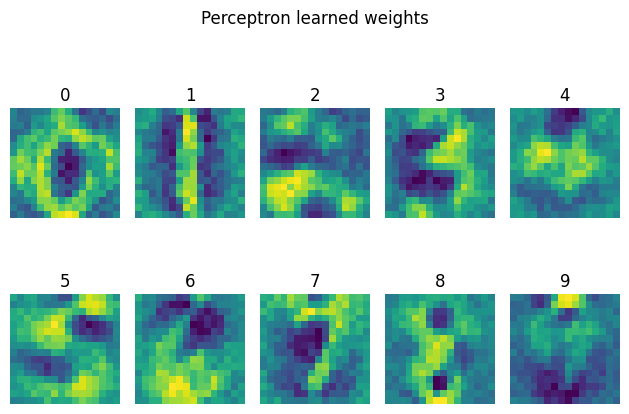

In [48]:
w = model.fc1.weight.detach().numpy()
fig, axes = plt.subplots(2,5)
axes = axes.flatten()
for i in range(w.shape[0]):
    axes[i].imshow(w[i].reshape(16,16))
    axes[i].set_title(i)
    axes[i].axis("off")
fig.suptitle("Perceptron learned weights")
plt.tight_layout()
plt.show()

Conclure sur l’importance des différentes parties de l’image en fonction
de la classe.